In [1]:
import numpy as np
import pandas as pd

def generate_tantrum_data_stochastic(n=1000, seed=4353):
    np.random.seed(seed)
    
    # Snacks and sugar
    snack = np.random.choice(['Goldfish', 'Apple', 'Carrots'], size=n)
    sugar = np.where(snack == 'Goldfish', 10, np.where(snack == 'Apple', 5, 2))
    
    # Time of day
    time_of_day = np.random.choice(['Morning', 'Afternoon', 'Evening'], size=n)
    
    # Base probability of tantrum
    p_base = {'Morning': 0.09, 'Afternoon': 0.25, 'Evening': 0.7}
    p_tant = np.array([p_base[t] for t in time_of_day])
    
    # Sugar amplifies probability
    sugar_effect_prob = np.where(time_of_day=='Afternoon', sugar*0.15, 0) + \
                        np.where(time_of_day=='Evening', sugar*0.3, 0)
    
    # Stochastic noise
    prob_noise = np.random.normal(0, 0.05, n)
    
    # Final probability
    p_tant = np.clip(p_tant + sugar_effect_prob + prob_noise, 0, 1)
    
    # Sample tantrum occurrence
    tantrum_occurs = np.random.binomial(1, p_tant, n)
    
    # Duration if tantrum occurs
    base_duration = 5
    duration_effect = sugar_effect_prob * 2
    # Scale duration with probability
    alpha = 2  # scaling factor for probability effect on duration
    uncontrollable_noise = np.random.normal(0, 0.5, n)
    
    t_tant = tantrum_occurs * np.clip(base_duration + duration_effect + alpha * p_tant + uncontrollable_noise, 0, None)
    
    # Assemble DataFrame
    df = pd.DataFrame({
        'snack_type': snack,
        'sugar_content': sugar,
        'time_of_day': time_of_day,
        'p_tant': p_tant,
        't_tant': t_tant
    })
    
    return df

# Example
df_stoch = generate_tantrum_data_stochastic()
df_stoch.head()


,snack_type,sugar_content,time_of_day,p_tant,t_tant
0,Goldfish,10,Afternoon,1.000000,9.713742
1,Carrots,2,Afternoon,0.528785,0.000000
2,Goldfish,10,Evening,1.000000,12.603639
3,Carrots,2,Evening,1.000000,7.439171
4,Carrots,2,Evening,1.000000,8.237744


In [2]:
df = generate_tantrum_data_stochastic()

In [3]:
import matplotlib.pyplot as plt

In [4]:
apple = df[df['snack_type'] == 'Apple'].copy()
fish = df[df['snack_type'] == 'Goldfish'].copy()
carrots = df[df['snack_type'] == 'Carrots'].copy()

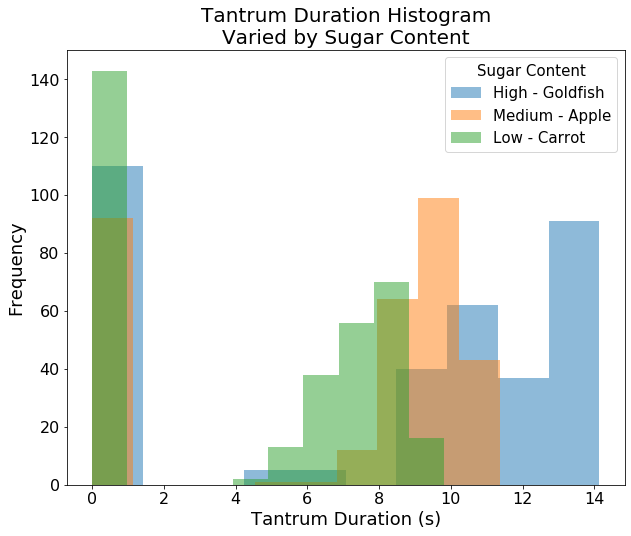

In [5]:
plt.figure(figsize = (10,8))

plt.hist(fish['t_tant'], alpha = 0.5, label = 'High - Goldfish')
plt.hist(apple['t_tant'], alpha = 0.5, label = 'Medium - Apple')
plt.hist(carrots['t_tant'], alpha = 0.5, label = 'Low - Carrot')

plt.xlabel('Tantrum Duration (s)', fontsize = 18)
plt.xticks(size = 16)

plt.ylabel('Frequency', fontsize = 18)
plt.yticks(size = 16)

plt.title('Tantrum Duration Histogram\nVaried by Sugar Content', fontsize = 20)

legend = plt.legend(title='Sugar Content', fontsize=15)  
legend.get_title().set_fontsize(15)
plt.savefig('sugar_hist.png')

plt.show()

### Hmm... appears to be higher dimensionality than just sugar content

In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('t_tant ~ C(snack_type) * C(time_of_day)', data=df).fit()
df_anova = sm.stats.anova_lm(model, typ=2)
print(df_anova)


                                    sum_sq     df            F         PR(>F)
C(snack_type)                  2151.698908    2.0   516.196171  2.464933e-154
C(time_of_day)                18228.466814    2.0  4373.039715   0.000000e+00
C(snack_type):C(time_of_day)   1253.354188    4.0   150.340884  1.648264e-100
Residual                       2065.429517  991.0          NaN            NaN


In [7]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['t_tant'],
                          groups=df['snack_type'] + "_" + df['time_of_day'],
                          alpha=0.05)
print(tukey)


             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
   Apple_Afternoon      Apple_Evening   1.8441  0.001   1.2249   2.4633   True
   Apple_Afternoon      Apple_Morning  -8.0478  0.001  -8.7227  -7.3729   True
   Apple_Afternoon  Carrots_Afternoon  -4.0977  0.001   -4.749  -3.4464   True
   Apple_Afternoon    Carrots_Evening   0.0253    0.9  -0.6088   0.6593  False
   Apple_Afternoon    Carrots_Morning  -7.6932  0.001  -8.3366  -7.0497   True
   Apple_Afternoon Goldfish_Afternoon   1.8593  0.001   1.2038   2.5149   True
   Apple_Afternoon   Goldfish_Evening   4.8297  0.001   4.2029   5.4564   True
   Apple_Afternoon   Goldfish_Morning  -7.7128  0.001  -8.3468  -7.0787   True
     Apple_Evening      Apple_Morning  -9.8919  0.001 -10.5006  -9.2832   True
     Apple_Evening  Carrots_Afternoon  -5.9418  0.00

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import matplotlib.pyplot as plt

# Run Tukey
tukey = pairwise_tukeyhsd(endog=df['t_tant'],
                          groups=df['snack_type'] + "_" + df['time_of_day'],
                          alpha=0.05)

print(tukey.summary())

# Optional: convert to DataFrame for plotting
tukey_df = pd.DataFrame(data=tukey.summary()[1:], columns=tukey.summary()[0])

# Example: add letters manually or via statsmodels add-ons for plot annotation


             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
   Apple_Afternoon      Apple_Evening   1.8441  0.001   1.2249   2.4633   True
   Apple_Afternoon      Apple_Morning  -8.0478  0.001  -8.7227  -7.3729   True
   Apple_Afternoon  Carrots_Afternoon  -4.0977  0.001   -4.749  -3.4464   True
   Apple_Afternoon    Carrots_Evening   0.0253    0.9  -0.6088   0.6593  False
   Apple_Afternoon    Carrots_Morning  -7.6932  0.001  -8.3366  -7.0497   True
   Apple_Afternoon Goldfish_Afternoon   1.8593  0.001   1.2038   2.5149   True
   Apple_Afternoon   Goldfish_Evening   4.8297  0.001   4.2029   5.4564   True
   Apple_Afternoon   Goldfish_Morning  -7.7128  0.001  -8.3468  -7.0787   True
     Apple_Evening      Apple_Morning  -9.8919  0.001 -10.5006  -9.2832   True
     Apple_Evening  Carrots_Afternoon  -5.9418  0.00

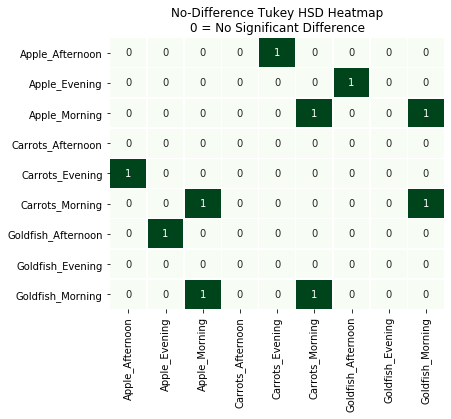

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Groups
group_names = tukey.groupsunique
n_groups = len(group_names)

# Initialize matrix: 1 = difference, 0 = no difference
diff_matrix = np.zeros((n_groups, n_groups))

# Unpack pair indices
i_indices, j_indices = tukey._multicomp.pairindices

# Fill matrix
for idx in range(len(i_indices)):
    i = i_indices[idx]
    j = j_indices[idx]
    pval = tukey.pvalues[idx]
    diff_matrix[i, j] = 0 if pval < 0.05 else 1  # 1 = no difference
    diff_matrix[j, i] = diff_matrix[i, j]

# Create DataFrame for seaborn
diff_df = pd.DataFrame(diff_matrix, index=group_names, columns=group_names)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(diff_df, annot=True, cmap='Greens', cbar=False, linewidths=0.5)
plt.title('No-Difference Tukey HSD Heatmap\n0 = No Significant Difference')
plt.show()


In [10]:
no_diff_pairs = []

i_indices, j_indices = tukey._multicomp.pairindices

for idx in range(len(i_indices)):
    i = i_indices[idx]
    j = j_indices[idx]
    pval = tukey.pvalues[idx]
    if pval > 0.05:
        pair = f"{group_names[i]} ↔ {group_names[j]}"
        no_diff_pairs.append(pair)

print("Pairs with NO significant difference:")
for pair in no_diff_pairs:
    print("•", pair)


Pairs with NO significant difference:
• Apple_Afternoon ↔ Carrots_Evening
• Apple_Evening ↔ Goldfish_Afternoon
• Apple_Morning ↔ Carrots_Morning
• Apple_Morning ↔ Goldfish_Morning
• Carrots_Morning ↔ Goldfish_Morning


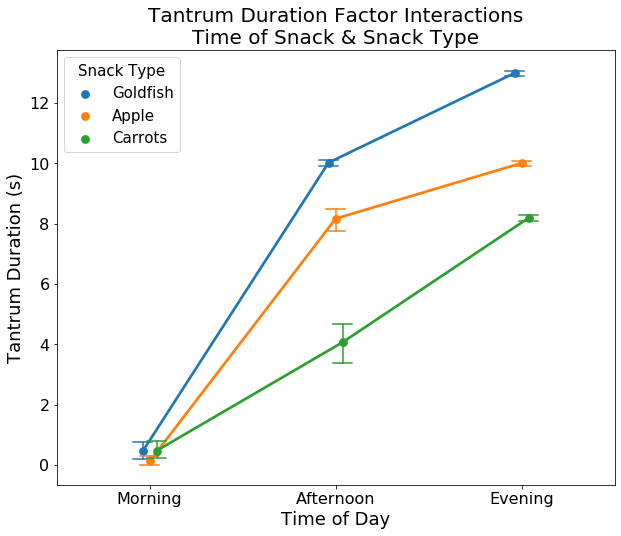

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,8))
sns.pointplot(data=df, x='time_of_day', y='t_tant', hue='snack_type', hue_order = ['Goldfish', 'Apple', 'Carrots'],   order=['Morning', 'Afternoon', 'Evening'],  
              dodge=True, markers='o', capsize=0.1, errwidth=1.5)
plt.title("Tantrum Duration Factor Interactions\nTime of Snack & Snack Type", fontsize = 20)

plt.ylabel('Tantrum Duration (s)', fontsize = 18)
plt.xticks(size = 16)

plt.xlabel('Time of Day', fontsize = 18)
plt.yticks(size = 16)

# plt.title('Tantrum Duration Effect\nFrom Time of Day and Snack Type', fon tsize = 20)

legend = plt.legend(title='Snack Type', fontsize=15)  
legend.get_title().set_fontsize(15)

plt.savefig('effect_chart.png')

plt.show()


In [12]:
ss_total = df_anova['sum_sq'].sum()
df_anova['eta_sq'] = df_anova['sum_sq'] / ss_total
print(df_anova[['sum_sq', 'eta_sq']])


                                    sum_sq    eta_sq
C(snack_type)                  2151.698908  0.090793
C(time_of_day)                18228.466814  0.769168
C(snack_type):C(time_of_day)   1253.354188  0.052886
Residual                       2065.429517  0.087153
